# PRACTICAL SESSION 04

## MODULES IMPORT

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import constants as const
from astropy import units as u

from scipy.stats import norm
from scipy.stats import uniform

In [5]:
# Setting the random number generator

rng = np.random.default_rng()

# 1 - INPUT GENERATION:

In [3]:
def psi(r):
  return 1 / np.sqrt(1 + r**2)

# Radius as a function of mass (useful to generate r with the inverse function method)
def radius(M):
  return 1 / np.sqrt(1 / M**(2/3) - 1)

def f(r, v):
  E = psi(r) - v**2 / 2
  out = np.zeros(len(v))
  out[E > 0] = v[E > 0]**2 * E[E > 0]**(7/2)
  return out

# 
def rej_samp(g, h, par, size=100):
    us = uniform.rvs(size=size)
    xs = h.rvs(size=size)
    mask = g(par, xs) / h.pdf(xs) > us
    return xs[mask]

In [18]:
def v_f(r, v):
    out = 0
    E = psi(r) - v**2 / 2
    if E > 0:
        out = v**2 * E**(7/2)
    return out

def v_sample(r, n=100000):
    out = []
    for i in r:
        us = uniform.rvs(size=n)
        xs = norm.rvs(size=n)
        mask = f(i, xs) / norm.pdf(xs) > us
        out.append(xs[mask][0])
    return out

In [20]:
# INITIAL CONDITIONS

N = 10 # number of p.cles
M = 1   # total mass (solar masses)
R = 1   # radius (solar radii)

# Masses
m = M / N * np.ones(N)

# Positions
phi = 2 * np.pi * rng.uniform(size=N)
the = np.arccos(1 - 2 * rng.uniform(size=N))
rho = radius(rng.uniform(size=N))

x = rho * np.sin(the) * np.cos(phi)
y = rho * np.sin(the) * np.sin(phi)
z = rho * np.cos(the)

# Velocities
vx = np.zeros(N)
vy = np.zeros(N)
vz = np.zeros(N)

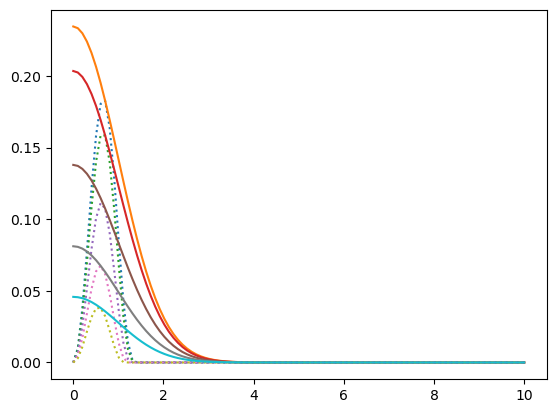

In [106]:
x = np.linspace(0, 10, 100)

for i in np.linspace(0, 1, 5):
    plt.plot(x, f(i, x), ':')
    k = max(f(i, x) / norm.pdf(x))
    plt.plot(x, k * norm.pdf(x))

(218,)


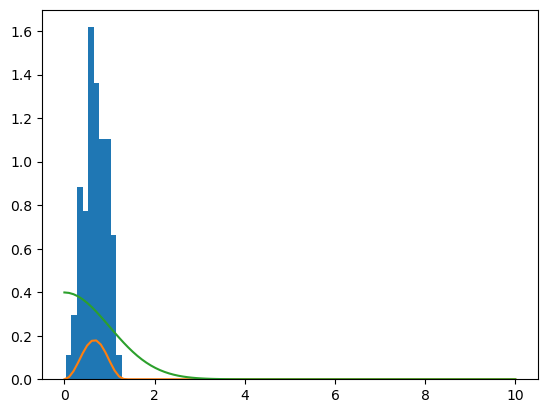

In [22]:
r = .1

sample = rej_samp(f, norm, r, 1000)

sample[sample < 0] = -sample[sample < 0]
plt.hist(sample, density=True)

plt.plot(x, f(r, x))
plt.plot(x, norm.pdf(x))

print(sample.shape)

In [23]:
v = v_sample(rho)
v

[0.22377164905396313,
 0.5026847728606785,
 0.10641178682259851,
 -0.35598233068922697,
 0.609575175793923,
 1.1887768875410971,
 -0.3948001625865818,
 0.8578141535507938,
 -0.39474863966086565,
 0.6828733599571298]

# Implement the stuff with np.meshgrid

In [18]:
def v_f(r, v):
    out = 0
    E = psi(r) - v**2 / 2
    if E > 0:
        out = v**2 * E**(7/2)
    return out

def v_sample(r, n=100000):
    out = []
    for i in r:
        us = uniform.rvs(size=n)
        xs = norm.rvs(size=n)
        mask = f(i, xs) / norm.pdf(xs) > us
        out.append(xs[mask][0])
    return out

In [37]:
r = np.linspace(0, 10, 5)
v = np.linspace(0, 5, 5)
r, v = np.meshgrid(r, v)

r

array([[ 0. ,  2.5,  5. ,  7.5, 10. ],
       [ 0. ,  2.5,  5. ,  7.5, 10. ],
       [ 0. ,  2.5,  5. ,  7.5, 10. ],
       [ 0. ,  2.5,  5. ,  7.5, 10. ],
       [ 0. ,  2.5,  5. ,  7.5, 10. ]])

In [38]:
v

array([[0.  , 0.  , 0.  , 0.  , 0.  ],
       [1.25, 1.25, 1.25, 1.25, 1.25],
       [2.5 , 2.5 , 2.5 , 2.5 , 2.5 ],
       [3.75, 3.75, 3.75, 3.75, 3.75],
       [5.  , 5.  , 5.  , 5.  , 5.  ]])

In [39]:
E = psi(r) - v**2 / 2
out = np.zeros(v.shape)
out[E > 0] = v[E > 0]**2 * E[E > 0]**(7/2)

print(E, '\n', out)

[[  1.           0.37139068   0.19611614   0.13216372   0.09950372]
 [  0.21875     -0.40985932  -0.58513386  -0.64908628  -0.68174628]
 [ -2.125       -2.75360932  -2.92888386  -2.99283628  -3.02549628]
 [ -6.03125     -6.65985932  -6.83513386  -6.89908628  -6.93174628]
 [-11.5        -12.12860932 -12.30388386 -12.36783628 -12.40049628]] 
 [[0.         0.         0.         0.         0.        ]
 [0.00764959 0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]


## Cool part

In [119]:
n = 5
rho = radius(rng.uniform(size=n))

#r, vs = np.meshgrid(rho, np.zeros(10))
vs, r = np.meshgrid(np.linspace(0, 5, 200), rho)
#print(r, '\n', vs)

E = psi(r) - vs**2 / 2
out = np.zeros(vs.shape)
out[E > 0] = vs[E > 0]**2 * E[E > 0]**(7/2)
k = np.max(out / norm.pdf(vs), axis=1)



vs = norm.rvs(size=vs.shape)
us = uniform.rvs(size=vs.shape)

E = psi(r) - vs**2 / 2
out = np.zeros(vs.shape)
out[E > 0] = vs[E > 0]**2 * E[E > 0]**(7/2)

mask = out / (k * norm.pdf(vs)) <= us

vs = np.abs(vs)
vs[mask] = -1


for i in range(n):
    #if vs[i].all() < 0:
    print(r[i][0], '\t', vs[i][vs[i] >= 0].shape, '\n')

ValueError: operands could not be broadcast together with shapes (5,) (5,200) 